In [ ]:
#electricity_consumption prediction model

In [34]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler

In [35]:
#Load Dataset
df=pd.read_csv("electricity_consumption_based_weather_dataset.csv")


In [36]:
#Explore Dataset
df.info()
df.columns
df.isnull().sum()
df.describe()
df["date"]=pd.to_datetime(df["date"])
df[df["AWND"].isnull()]
df['date'].is_monotonic_increasing #check for choronological ordering

<class 'pandas.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1433 non-null   str    
 1   AWND               1418 non-null   float64
 2   PRCP               1433 non-null   float64
 3   TMAX               1433 non-null   float64
 4   TMIN               1433 non-null   float64
 5   daily_consumption  1433 non-null   float64
dtypes: float64(5), str(1)
memory usage: 67.3 KB


True

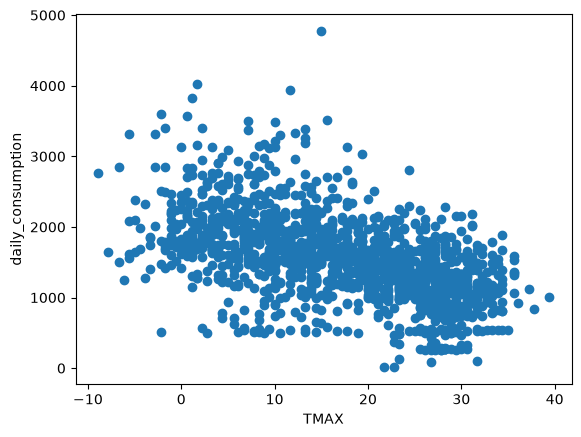

In [65]:
#EDA part
plt.scatter(df["TMAX"],df["daily_consumption"])#negative relationhip(x increases y decreases)
plt.xlabel("TMAX")
plt.ylabel("daily_consumption")
plt.savefig("Images/TMAX vs Daily Electricity Consumption.png")


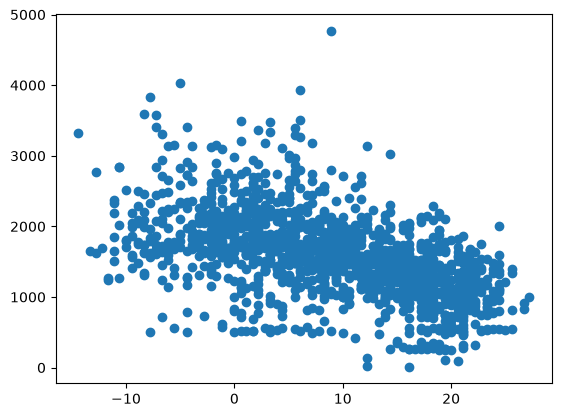

In [38]:
plt.scatter(df["TMIN"],df["daily_consumption"])#negative realionship(x increases y decreases)

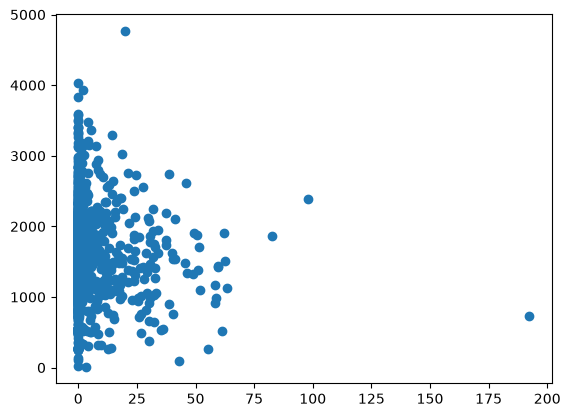

In [39]:
plt.scatter(df["PRCP"],df["daily_consumption"])#no realtionship/weak realtionship why?
#bcz mostly occurences are at 0 and for higher prcp there is no data

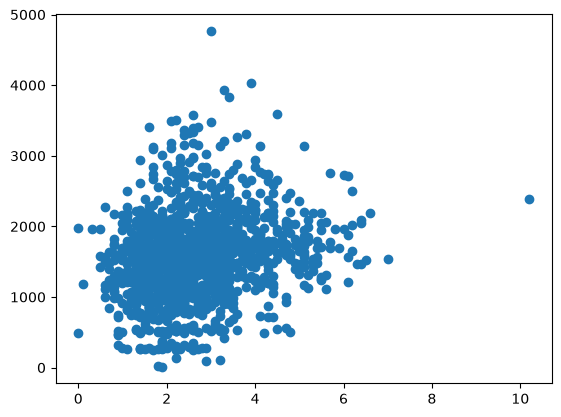

In [40]:
plt.scatter(df["AWND"],df["daily_consumption"])#no realtionship/weak realtionship why?
#bcz x increases but y has no constant direction sometimes it increases and sometimes decreases

In [41]:
#Data Cleaning
#interpolation(missing values in AWND column)
df["AWND"]=df["AWND"].interpolate()
df.isnull().sum()


date                 0
AWND                 0
PRCP                 0
TMAX                 0
TMIN                 0
daily_consumption    0
dtype: int64

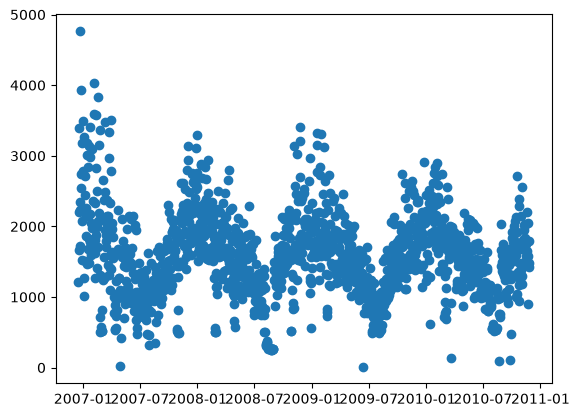

In [42]:
plt.scatter(df["date"],df["daily_consumption"])

In [43]:
#Feature Engineering
df["month"]=df["date"].dt.month
df["day_of_week"]=df["date"].dt.day_name()
df["year"]=df["date"].dt.year
df


,date,AWND,PRCP,TMAX,TMIN,daily_consumption,month,day_of_week,year
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176,12,Saturday,2006
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460,12,Sunday,2006
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826,12,Monday,2006
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194,12,Tuesday,2006
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748,12,Wednesday,2006
...,...,...,...,...,...,...,...,...,...
1428,2010-11-22,2.7,0.0,18.3,7.2,2041.536,11,Monday,2010
1429,2010-11-23,3.1,0.0,16.1,10.0,1577.536,11,Tuesday,2010
1430,2010-11-24,4.3,0.0,10.0,5.0,1796.248,11,Wednesday,2010
1431,2010-11-25,1.6,1.5,7.8,3.9,1431.164,11,Thursday,2010


<Axes: title={'center': 'daily_consumption'}, xlabel='month'>

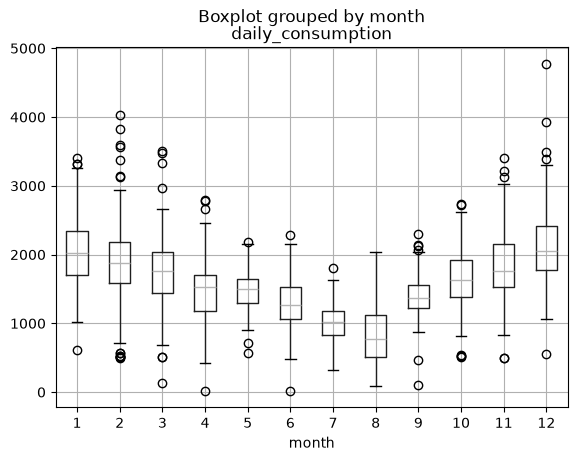

In [44]:
df.boxplot(column="daily_consumption", by="month")


<Axes: title={'center': 'daily_consumption'}, xlabel='year'>

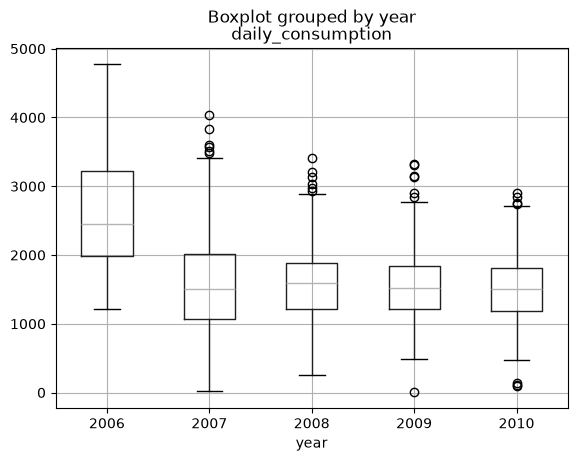

In [45]:
df.boxplot(column="daily_consumption", by="year")

<Axes: title={'center': 'daily_consumption'}, xlabel='day_of_week'>

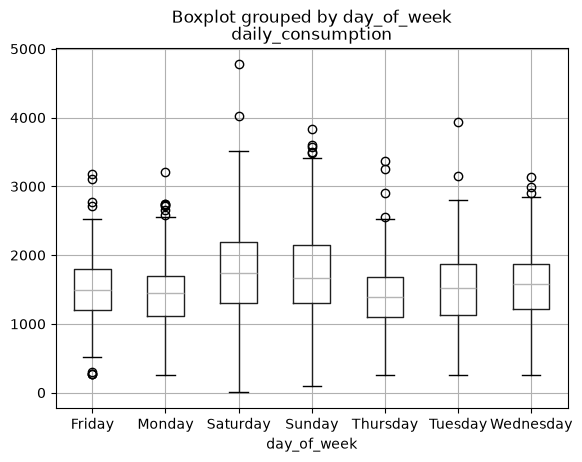

In [46]:
df.boxplot(column="daily_consumption", by="day_of_week")

In [48]:
#Feature Engineering
#cyclical encoding
df['month_sin']=np.sin(2*np.pi*df["month"]/12.0)
df['month_cos']=np.cos(2*np.pi*df["month"]/12.0)
df["day_num"]=df["date"].dt.dayofweek
df['day_sin']=np.sin(2*np.pi*df['day_num']/7.0)
df['day_cos']=np.cos(2*np.pi*df['day_num']/7.0)

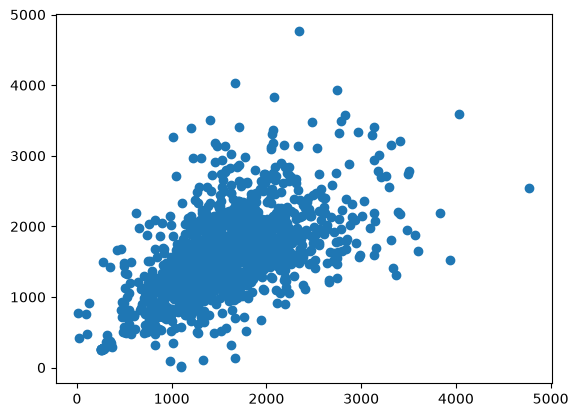

In [49]:
#Feature Engineering
df["previous_day_consumption"]=df['daily_consumption'].shift(1)
plt.scatter(df['previous_day_consumption'],df["daily_consumption"])

In [50]:
df["previous_day_consumption"].corr(df["daily_consumption"])


np.float64(0.6035779293756024)

In [51]:
df.corr(numeric_only=True)["daily_consumption"].sort_values(ascending=False)

daily_consumption           1.000000
previous_day_consumption    0.603578
month_cos                   0.520143
month_sin                   0.294234
AWND                        0.236338
day_num                     0.156429
day_cos                     0.038981
PRCP                       -0.036427
month                      -0.079215
year                       -0.093818
day_sin                    -0.134354
TMAX                       -0.525494
TMIN                       -0.526822
Name: daily_consumption, dtype: float64

In [52]:
temp=df.copy()
temp=temp.dropna()
temp = temp.reset_index(drop=True)

In [53]:
#Select Final Features
X=temp.iloc[:,[3,4,9,10,14]]
X
Y=temp.iloc[:,-10]
Y

0       3390.460
1       2203.826
2       1666.194
3       2225.748
4       1716.624
          ...   
1427    2041.536
1428    1577.536
1429    1796.248
1430    1431.164
1431    1488.104
Name: daily_consumption, Length: 1432, dtype: float64

In [54]:
#Train/Test Split
X_train = X.iloc[:int(len(X)*0.8)]
X_test = X.iloc[int(len(X)*0.8):]

y_train = Y.iloc[:int(len(Y)*0.8)]
y_test = Y.iloc[int(len(Y)*0.8):]

In [55]:
#Preprocessing
#standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [56]:
#model training
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-59.44, 84. ,128.91,227.51,234.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1593
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[61.02,33.76,25.77,12.45, 6.5 ]"


In [57]:
#model prediction
predictions=lr.predict(X_test_scaled)

In [58]:
#Evaluation
#comparison
result=pd.DataFrame({
    "Actual electricity consumption":y_test.values,
    "Predicted electricity consumption":predictions
})
result
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", ascending=False)

,Feature,Coefficient
4,previous_day_consumption,234.009590
3,month_cos,227.513126
2,month_sin,128.912566
1,TMIN,84.003831
0,TMAX,-59.443122


In [59]:
print("MAE",mean_absolute_error(y_test,predictions))
print("MSE",mean_squared_error(y_test,predictions))
print("RMSE",np.sqrt(mean_squared_error(y_test,predictions)))
print("R2_score",r2_score(y_test,predictions))
lr.intercept_

MAE 274.7549033618469
MSE 139022.6537144016
RMSE 372.85741740563725
R2_score 0.36472090261673784


np.float64(1592.8232436681224)

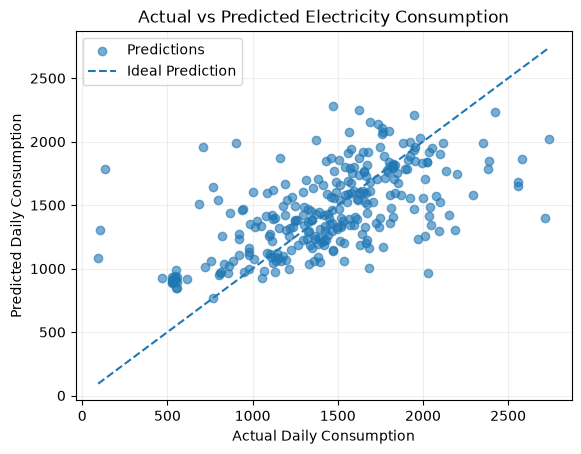

In [67]:
# Visualization
plt.scatter(
    y_test,
    predictions,
    alpha=0.6,
    label="Predictions"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Ideal Prediction"
)

plt.xlabel("Actual Daily Consumption")
plt.ylabel("Predicted Daily Consumption")
plt.title("Actual vs Predicted Electricity Consumption")
plt.legend()
plt.grid(alpha=0.2)
plt.savefig("Images/Actual vs Predicted Electricity Consumption.png")
plt.show()